In [1]:
### check python version
from platform import python_version

print(python_version())


3.12.13


In [2]:
### upload file from local hard drive
from google.colab import files
uploaded = files.upload()

Saving AAPL.csv to AAPL (2).csv


In [3]:
import pandas as pd

df = pd.read_csv("AAPL.csv")
# checking first 5 rows
df.head(5)
# checking for number of missing values in columns
df.isna().sum(axis=0) # no missing values/NaNs in each column
    # for the missing values/NaNs in each row change to axis=1

### separating variables
# Explanatory variables
X = df.drop(['Adj Close', 'Date'], axis = 1)
    # we drop the date column since the data type str could cause problems during linear regression
    # alternatively one could convert it into three columns which represent day, month, year
    # note that each row represents a day
# Target variable
y = df['Adj Close']

### splitting into training and test sets
# importing function from scikit-learn submodule
from sklearn.model_selection import train_test_split
# training set (85%) and test set (15%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)
    # chose an integer for random_state for reproducability
# import LinearRegression class
from sklearn.linear_model import LinearRegression

### training the model with linear regression
# instantiate model
lr = LinearRegression()
# training
lr.fit(X_train, y_train)
# prediction of target variable for train dataset
y_pred_train = lr.predict(X_train)
# prediction of the target variable for test dataset
y_pred_test = lr.predict(X_test)

### evaluating model performance
## using mean squared error implemented in scikit-learn
from sklearn.metrics import mean_squared_error

# calculate MSE between target variable and the predictions for training dataset
mse_train = mean_squared_error(y_train, y_pred_train)

# calculate MSE between target variable and the predictions for test dataset
mse_test = mean_squared_error(y_test, y_pred_test)

print("MSE train lr:", mse_train) # approx 5.39
print("MSE test lr:", mse_test) # approx 5.54

## using mean absolute error
from sklearn.metrics import mean_absolute_error

# calculate MAE between target variable and the predictions for training dataset
mae_train = mean_absolute_error(y_train, y_pred_train)

# calculate MAE between target variable and the predictions for training dataset
mae_test = mean_absolute_error(y_test, y_pred_test)

print("MAE train lr:", mae_train)
print("MAE test lr:", mae_test)

mean_close_adj = df['Adj Close'].mean()

print("\nRelative error", mae_test / mean_close_adj)
    # MAE is approx 5% of the average adjusted closing price!
    # note: 0% would mean perfect predictions


MSE train lr: 5.388438180582269
MSE test lr: 5.540436607658267
MAE train lr: 1.502992653153365
MAE test lr: 1.5126829513291238

Relative error 0.04947196344531302


Text(0, 0.5, 'Predicted')

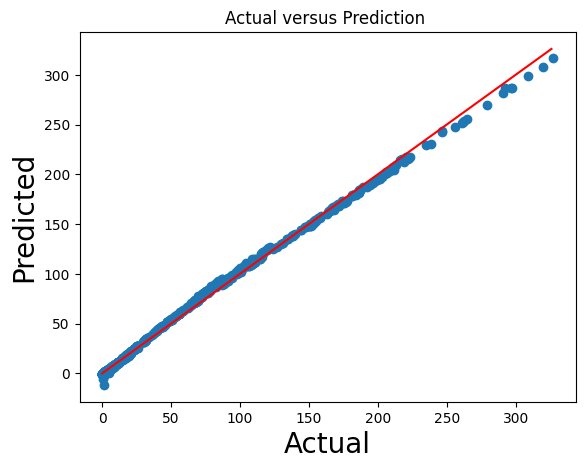

In [4]:
### matplot scatter plot for comparing test data with prediction
import numpy as np
import matplotlib.pyplot as plt
import math
# determining the max value in test and pred values
y_new = np.array([y_test,y_pred_test]).flatten()
np.shape(y_new)
d = math.floor(max(y_new))
rn = range(d)
# defining identity to compare accuracy of scatter plot
def f(x):
  return x

fig = plt.figure()
plt.scatter(y_test, y_pred_test)

plt.plot(rn, f(rn), color='red')
plt.title('Actual versus Prediction ')
plt.xlabel('Actual', fontsize=20)
plt.ylabel('Predicted', fontsize=20)